In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import sirf.Utilities
import sirf.Reg as Reg
import numpy as np
import stir
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
import shutil
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

## Evaluate OSEM and OSEM-RM Reconstruction Performance

The quality of the reconstructed Tc-99m and Lu-177 images is evaluated using the **recovery coefficient (RC)** of the six NEMA spheres.

The known digital activity distribution provides a reference against which the reconstructed sphere activity can be compared.

In this step:

- OSEM reconstructions from **10 to 100 subiterations** are loaded.
- The NEMA **sphere masks** are used to define the regions for quantitative analysis.
- An **image calibration factor (ICF)** is calculated to account for differences in global image scaling.
- The **recovery coefficient** is calculated for each sphere at every reconstruction subiteration.
- RC is plotted as a function of subiteration to investigate **reconstruction convergence** and the effect of **sphere size on activity recovery**.
- The calibrated reconstruction at **100 subiterations** is displayed alongside the known activity distribution for visual comparison.

Ideally, a recovery coefficient of **1** indicates complete recovery of the known activity within the corresponding sphere. Smaller spheres are expected to show lower recovery due to the limited spatial resolution of the SPECT imaging system.

In [24]:
verbose = False

config_dict = {
    "tc99m": {
        "image_type": "tc99m_128",
        "source_name": "nema_tc_act.hv",
        "masks_name": "masks_tc.npz",
    },
    "lu177": {
        "image_type": "lu177_128",
        "source_name": "nema_lu_act.hv",
        "masks_name": "masks_lu.npz",
    },   
}
diametre_mm = [13, 17, 22, 28, 37, 60]


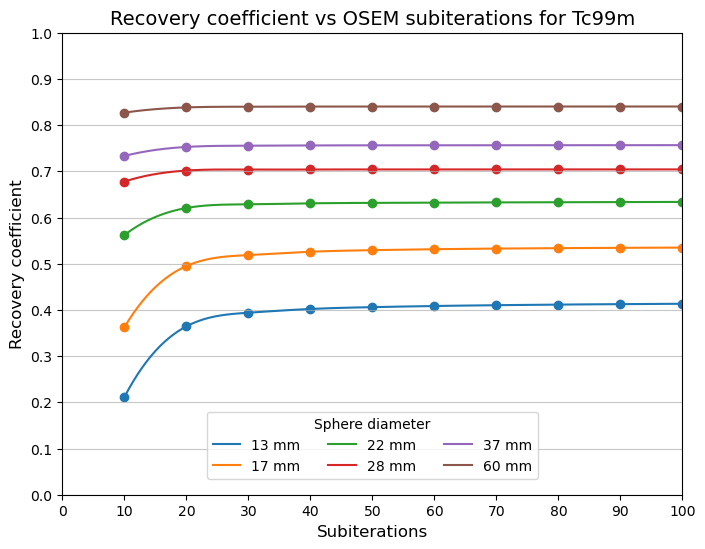

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Tc99m Ground Truth'}>,
        <Axes: title={'center': 'Tc99m OSEM reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

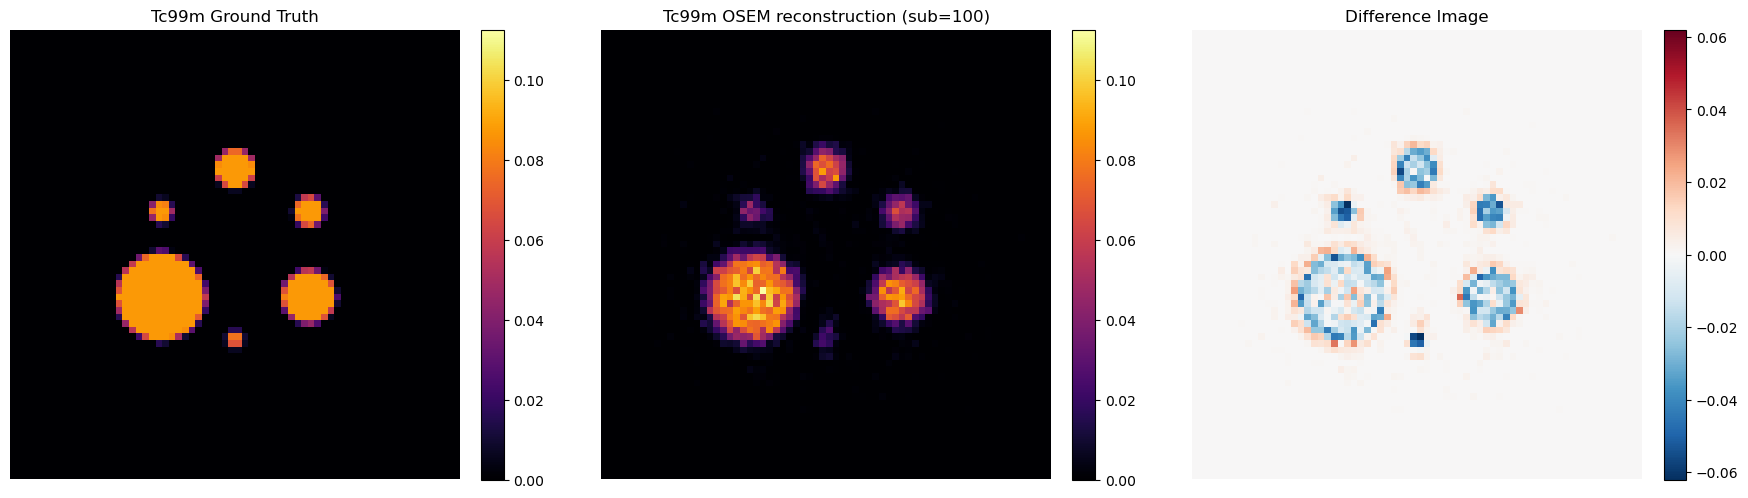

In [45]:
nuclide = "tc99m"
recon_type = "osem"

recon_prefix = f"{nuclide}_sim_{recon_type}"

input_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "input"
recon_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / config_dict[nuclide]["source_name"])
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / config_dict[nuclide]["masks_name"])
)

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

recon_type_neat = recon_type.upper().replace("_","-")
utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs {recon_type_neat} subiterations for {nuclide.capitalize()}"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"{nuclide.capitalize()} Ground Truth", 
        f"{nuclide.capitalize()} {recon_type_neat} reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)

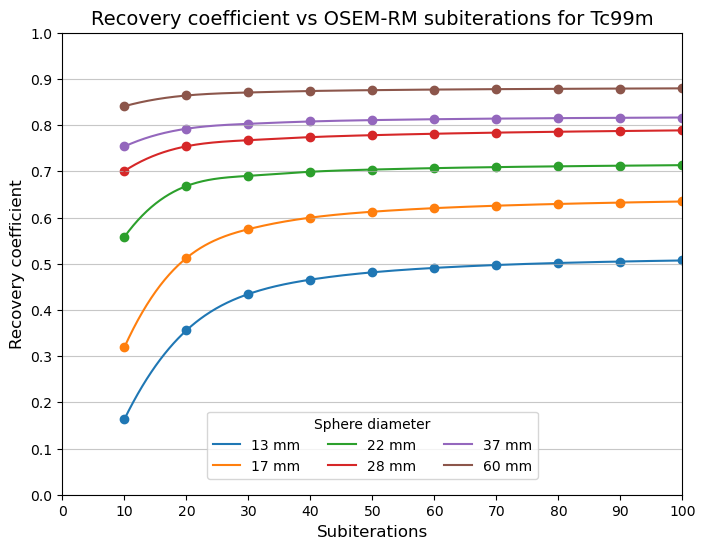

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Tc99m Ground Truth'}>,
        <Axes: title={'center': 'Tc99m OSEM-RM reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

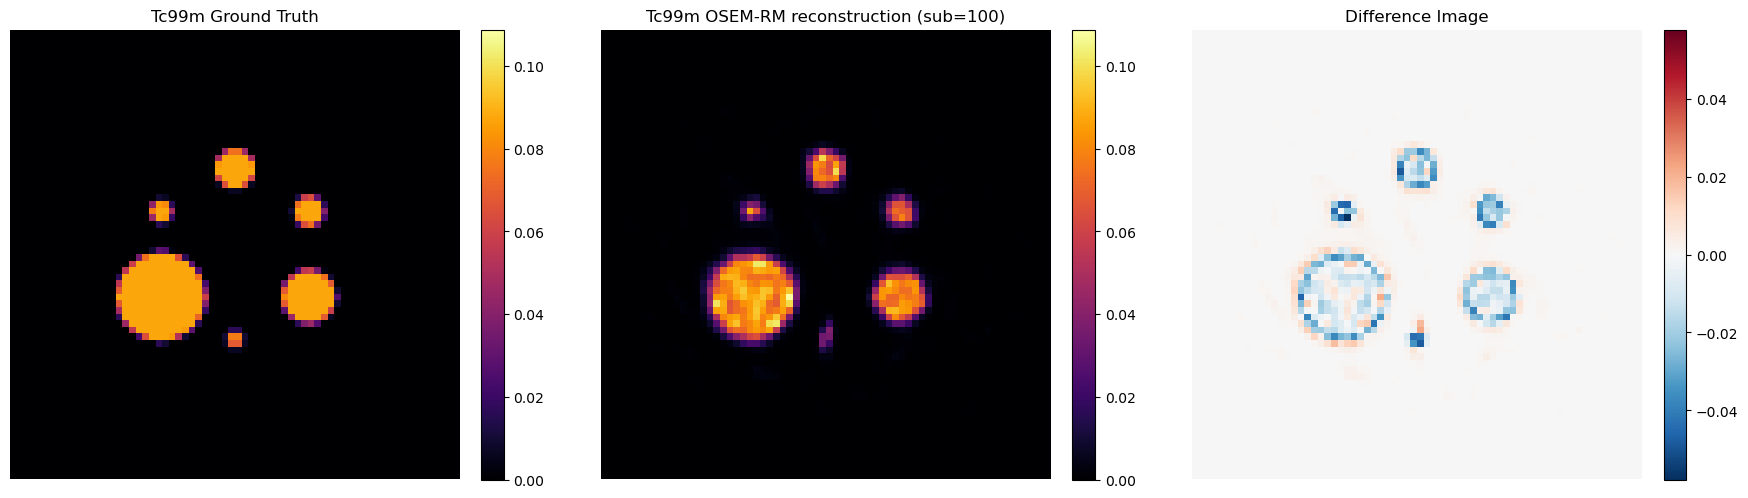

In [46]:
nuclide = "tc99m"
recon_type = "osem_rm"

recon_prefix = f"{nuclide}_sim_{recon_type}"

input_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "input"
recon_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / config_dict[nuclide]["source_name"])
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / config_dict[nuclide]["masks_name"])
)

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

recon_type_neat = recon_type.upper().replace("_","-")
utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs {recon_type_neat} subiterations for {nuclide.capitalize()}"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"{nuclide.capitalize()} Ground Truth", 
        f"{nuclide.capitalize()} {recon_type_neat} reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)

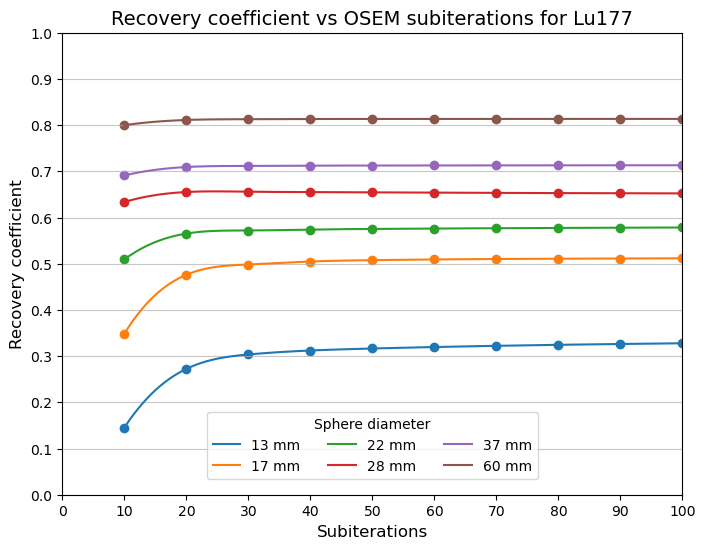

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Lu177 Ground Truth'}>,
        <Axes: title={'center': 'Lu177 OSEM reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

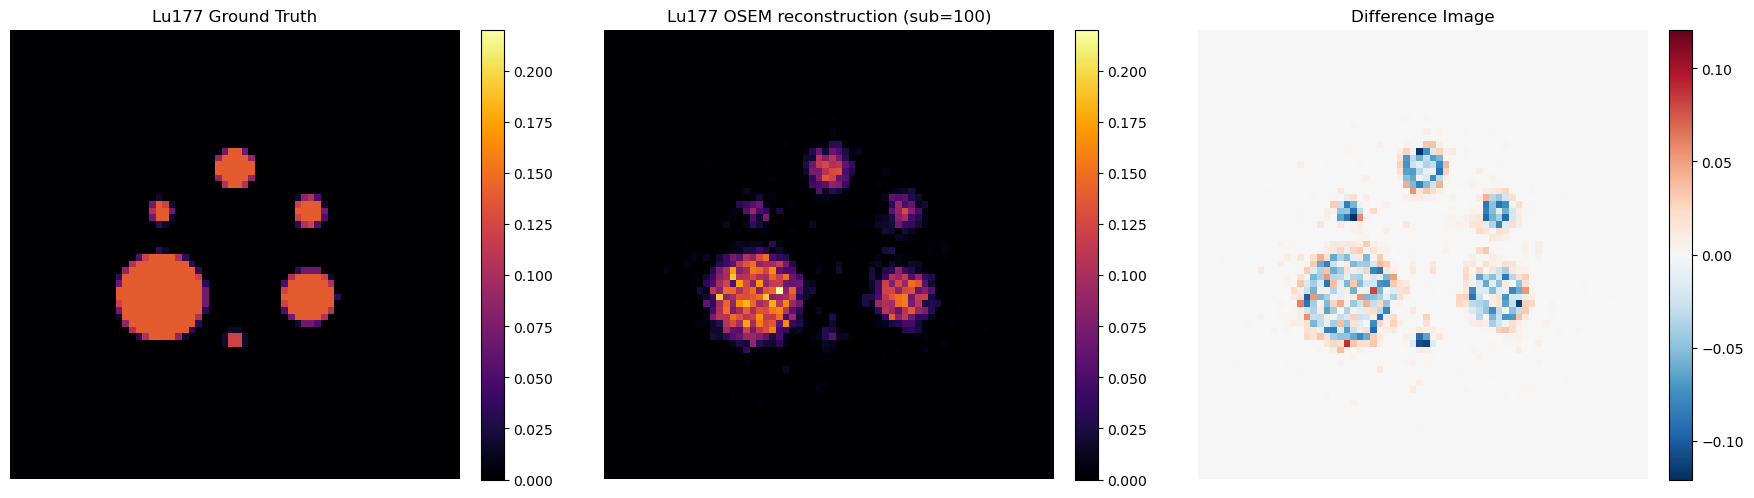

In [47]:
nuclide = "lu177"
recon_type = "osem"

recon_prefix = f"{nuclide}_sim_{recon_type}"

input_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "input"
recon_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / config_dict[nuclide]["source_name"])
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / config_dict[nuclide]["masks_name"])
)

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

recon_type_neat = recon_type.upper().replace("_","-")
utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs {recon_type_neat} subiterations for {nuclide.capitalize()}"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"{nuclide.capitalize()} Ground Truth", 
        f"{nuclide.capitalize()} {recon_type_neat} reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)

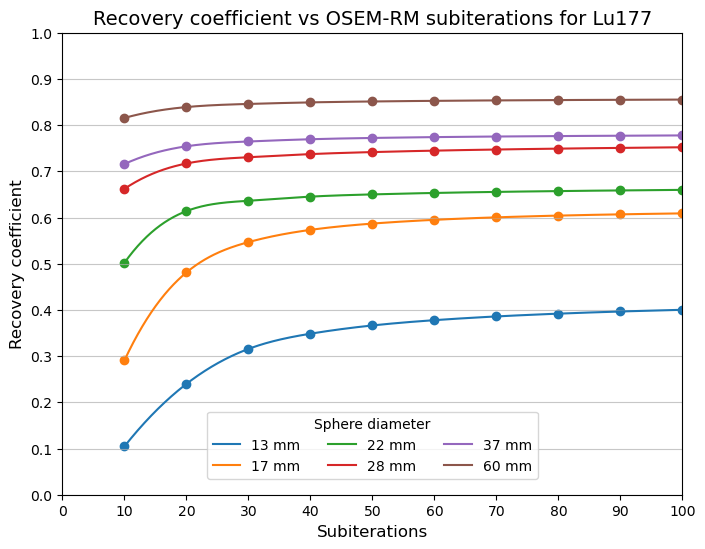

(<Figure size 1800x500 with 6 Axes>,
 array([<Axes: title={'center': 'Lu177 Ground Truth'}>,
        <Axes: title={'center': 'Lu177 OSEM-RM reconstruction (sub=100)'}>,
        <Axes: title={'center': 'Difference Image'}>], dtype=object))

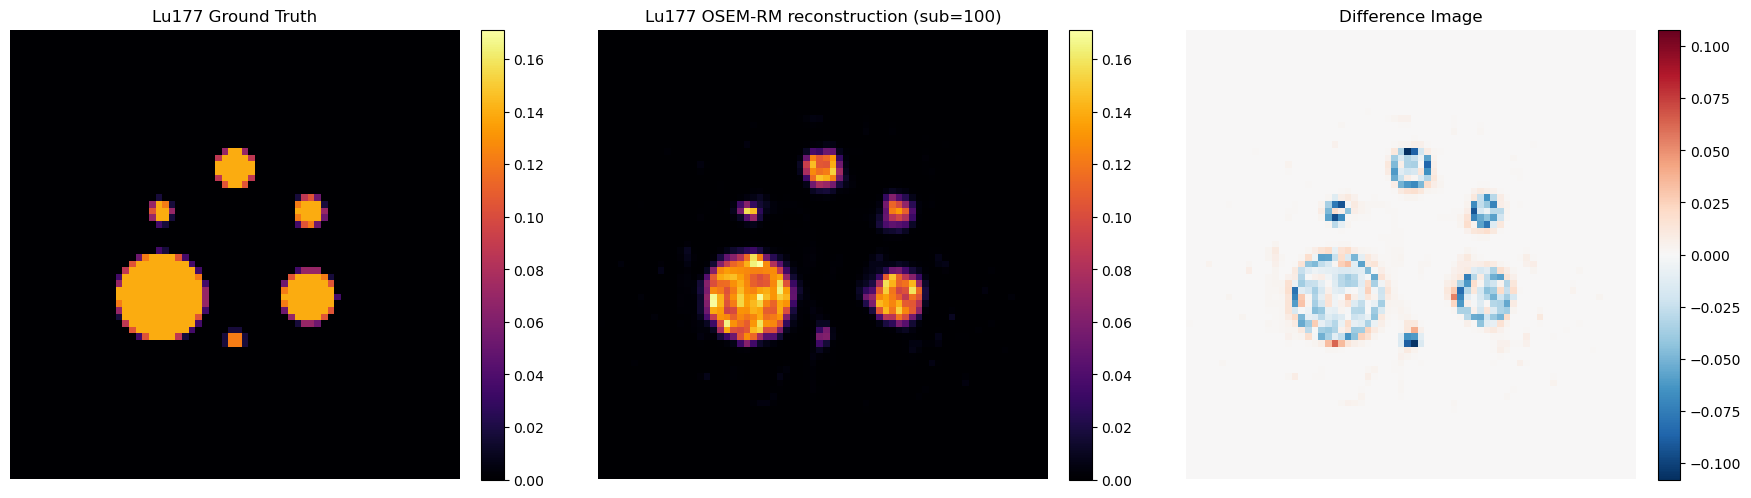

In [48]:
nuclide = "lu177"
recon_type = "osem_rm"

recon_prefix = f"{nuclide}_sim_{recon_type}"

input_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "input"
recon_dir = demo_path / "simind_data" / config_dict[nuclide]["image_type"] / "recons" / recon_type

# Load source image
nema_act_arr = spect.ImageData(
    str(input_dir / config_dict[nuclide]["source_name"])
).as_array()

# Load reconstructions
subit_list = np.arange(10, 101, 10)

recon_dict = {
    str(it): spect.ImageData(
        str(recon_dir / f"{recon_prefix}_{it}.hv")
    ).as_array()
    for it in subit_list
}

# Load sphere masks
masks_dict = dict(
    np.load(input_dir / config_dict[nuclide]["masks_name"])
)

rc_data, icf = utils.calculate_recovery_coefficients(
    source=nema_act_arr,
    recon_dict=recon_dict,
    masks_dict=masks_dict,
    subiterations=subit_list,
    verbose=verbose
)

recon_type_neat = recon_type.upper().replace("_","-")
utils.plot_recovery_coefficients(
    subiterations=subit_list,
    rc_data=rc_data,
    diameters_mm=diametre_mm,
    title=f"Recovery coefficient vs {recon_type_neat} subiterations for {nuclide.capitalize()}"
)

idx = (56,slice(30,98),slice(30,98))
subit = 100
recon_subit = recon_dict[str(subit)] / icf

vmax = max(np.max(nema_act_arr[idx]), np.max(recon_subit[idx]))

utils.display_arr(
    arr_3d=[nema_act_arr, recon_subit, recon_subit-nema_act_arr],
    idx=idx,
    vmax=[vmax, vmax, np.max(np.abs(nema_act_arr[idx] - recon_subit[idx]))],
    titles=[f"{nuclide.capitalize()} Ground Truth", 
        f"{nuclide.capitalize()} {recon_type_neat} reconstruction (sub={subit})",
        "Difference Image"
        ],
    cmap=["inferno", "inferno", "RdBu_r"]
)